“Global Power Plant Database”

According to the report Distribution of World Power Plants is being presented as follows

In [ ]:

HTML('<iframe src="https://datasets.wri.org/datasets/global-power-plant-database/embed/map?map=eyJ2aWV3U3RhdGUiOnsibG9uZ2l0dWRlIjotNDUuNzAzNjc1MTk2ODgzNzgsImxhdGl0dWRlIjotMzEuMDQwMTgxMjA3MjI3MSwiem9vbSI6MC45MzI5MDM5NTQ1ODgyOTE3LCJwaXRjaCI6MCwiYmVhcmluZyI6MCwicGFkZGluZyI6eyJ0b3AiOjAsImJvdHRvbSI6MCwibGVmdCI6MCwicmlnaHQiOjB9fSwiYmFzZW1hcCI6ImxpZ2h0IiwiYm91bmRhcmllcyI6ZmFsc2UsImxhYmVscyI6ImRhcmsiLCJhY3RpdmVMYXllckdyb3VwcyI6W3siZGF0YXNldElkIjoiNTM2MjNkZmQtM2RmNi00ZjE1LWEwOTEtNjc0NTdjZGI1NzFmIiwibGF5ZXJzIjpbIjJhNjk0Mjg5LWZlYzktNGJmZS1hNmQyLTU2YzM4NjRlYzM0OSJdfV0sImJvdW5kcyI6eyJiYm94IjpudWxsLCJvcHRpb25zIjp7fX0sImxheWVyc1BhcnNlZCI6W1siMmE2OTQyODktZmVjOS00YmZlLWE2ZDItNTZjMzg2NGVjMzQ5Iix7InZpc2liaWxpdHkiOnRydWUsImFjdGl2ZSI6dHJ1ZSwib3BhY2l0eSI6MSwiekluZGV4IjoxMX1dXX0=" width="600" height="400" /></iframe>')from IPython.display import HTML

/usr/local/lib/python3.10/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Uploading the database

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()
import io
file_name = list(uploaded.keys())[0]
glpdf = pd.read_csv(io.BytesIO(uploaded[file_name]))
glpdf.head()

Saving global_power_plant_database.csv to global_power_plant_database (7).csv


In [23]:
glpdf = pd.read_csv(io.BytesIO(uploaded[file_name]))
glpdf.head()
print(file_name)



global_power_plant_database (7).csv


<ipython-input-23-014978bdc09d>:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  glpdf = pd.read_csv(io.BytesIO(uploaded[file_name]))


In [16]:
glpdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 non-null  float64
 12  owner                           

In [19]:
glpdf.isnull().sum()

,0
country,0
country_long,0
name,0
gppd_idnr,0
capacity_mw,0
latitude,0
longitude,0
primary_fuel,0
other_fuel1,32992
other_fuel2,34660


Drop Columns with High Missing Values: likeother_fuel1, other_fuel2, other_fuel3, and generation_data_source

In [24]:
glpdf.columns


Index(['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw',
       'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2',
       'other_fuel3', 'commissioning_year', 'owner', 'source', 'url',
       'geolocation_source', 'wepp_id', 'year_of_capacity_data',
       'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015',
       'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018',
       'generation_gwh_2019', 'generation_data_source',
       'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014',
       'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016',
       'estimated_generation_gwh_2017', 'estimated_generation_note_2013',
       'estimated_generation_note_2014', 'estimated_generation_note_2015',
       'estimated_generation_note_2016', 'estimated_generation_note_2017'],
      dtype='object')

In [25]:
# Dropping columns with excessive missing values
columns_to_drop = ['other_fuel1', 'other_fuel2', 'other_fuel3', 'generation_data_source']
glpdf.drop(columns=columns_to_drop, inplace=True)

# Filling  missing values in categorical columns
glpdf['owner'] = glpdf['owner'].fillna('Unknown')
glpdf['source'] = glpdf['source'].fillna('Unknown')
glpdf['url'] = glpdf['url'].fillna('Unknown')

# Ensuring  commissioning_year is integer
glpdf['commissioning_year'] = glpdf['commissioning_year'].fillna(glpdf['commissioning_year'].median()).astype(int)

# Verify if columns have been dropped and missing values handled
print("Columns after dropping:", glpdf.columns)
print("\nMissing values after handling:")
print(glpdf.isnull().sum())


Columns after dropping: Index(['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw',
       'latitude', 'longitude', 'primary_fuel', 'commissioning_year', 'owner',
       'source', 'url', 'geolocation_source', 'wepp_id',
       'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014',
       'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017',
       'generation_gwh_2018', 'generation_gwh_2019',
       'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014',
       'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016',
       'estimated_generation_gwh_2017', 'estimated_generation_note_2013',
       'estimated_generation_note_2014', 'estimated_generation_note_2015',
       'estimated_generation_note_2016', 'estimated_generation_note_2017'],
      dtype='object')

Missing values after handling:
country                               0
country_long                          0
name                                  0
gppd_idnr         

In [30]:

# Step 1: Convert DataFrame to NumPy array
data_array = glpdf.to_numpy()

# Step 2: Handle missing values in numerical columns
for col_idx in range(data_array.shape[1]):
    # Identify numeric columns using the original DataFrame
    if np.issubdtype(glpdf.iloc[:, col_idx].dtype, np.number):
        # Calculate column median, ignoring NaN
        median_val = np.nanmedian(glpdf.iloc[:, col_idx].values)
        # Replace NaN with the median
        data_array[:, col_idx] = np.where(pd.isnull(data_array[:, col_idx]), median_val, data_array[:, col_idx])

# Step 3: Convert the NumPy array back to a DataFrame
glpdf_cleaned = pd.DataFrame(data_array, columns=glpdf.columns)

# Step 4: Restore proper data types
for col in glpdf.columns:
    glpdf_cleaned[col] = glpdf_cleaned[col].astype(glpdf[col].dtype)

# Step 5: Verify the cleaned DataFrame
print("\nRemaining missing values after cleaning:")
print(glpdf_cleaned.isnull().sum())






Remaining missing values after cleaning:
country                           0
country_long                      0
name                              0
gppd_idnr                         0
capacity_mw                       0
latitude                          0
longitude                         0
primary_fuel                      0
commissioning_year                0
owner                             0
source                            0
url                               0
geolocation_source                0
generation_gwh_2013               0
generation_gwh_2014               0
generation_gwh_2015               0
generation_gwh_2016               0
generation_gwh_2017               0
generation_gwh_2018               0
generation_gwh_2019               0
estimated_generation_gwh_2013     0
estimated_generation_gwh_2014     0
estimated_generation_gwh_2015     0
estimated_generation_gwh_2016     0
estimated_generation_gwh_2017     0
estimated_generation_note_2013    0
estimated_generation_n

In [32]:

# Summary statistics for numerical columns
summary_stats = glpdf_cleaned.describe()
print(summary_stats)

        capacity_mw      latitude     longitude  commissioning_year  \
count  34936.000000  34936.000000  34936.000000        34936.000000   
mean     163.355148     32.816637     -6.972803         2002.184910   
std      489.636072     22.638603     78.405850           17.248597   
min        1.000000    -77.847000   -179.977700         1896.000000   
25%        4.900000     29.256475    -77.641550         2007.000000   
50%       16.745000     39.727750     -2.127100         2007.000000   
75%       75.344250     46.263125     49.502675         2007.000000   
max    22500.000000     71.292000    179.388700         2020.000000   

       generation_gwh_2013  generation_gwh_2014  generation_gwh_2015  \
count         34936.000000         34936.000000         34936.000000   
mean            127.988808           154.588104           199.008635   
std             957.739058          1046.708882          1266.608895   
min            -947.600000          -989.619000          -864.428000   


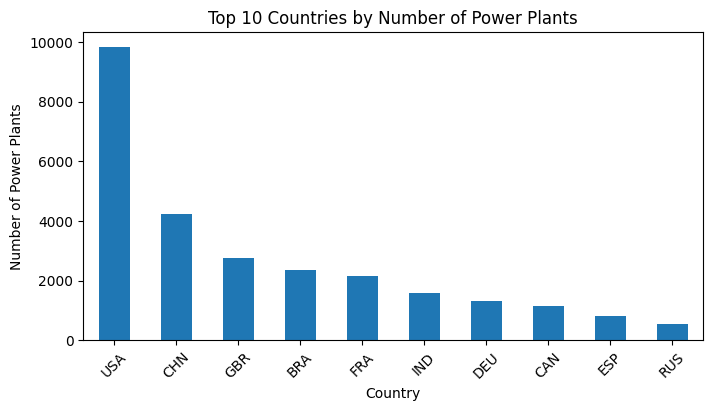

In [46]:

# Top 10 countries by number of power plants
country_distribution = glpdf_cleaned['country'].value_counts().head(10)

# Distribution by fuel type
fuel_distribution = glpdf_cleaned['primary_fuel'].value_counts()

# Visualization: Top 10 countries
plt.figure(figsize=(8, 4))
country_distribution.plot(kind='bar')
plt.title('Top 10 Countries by Number of Power Plants')
plt.xlabel('Country')
plt.ylabel('Number of Power Plants')
plt.xticks(rotation=45)
plt.show()


In [34]:

# Group by fuel type and calculate statistics
fuel_stats = glpdf_cleaned.groupby('primary_fuel')['capacity_mw'].agg(['mean', 'median', 'std'])
print("Power Output Statistics by Fuel Type:")
print(fuel_stats)


Power Output Statistics by Fuel Type:
                       mean      median          std
primary_fuel                                        
Biomass           23.972938     9.45000    39.461805
Coal             843.579828   600.00000   888.187187
Cogeneration      98.731707    31.90000   283.428252
Gas              373.449375   147.50000   560.934146
Geothermal        67.130952    30.00000   114.640890
Hydro            147.171551    20.00000   549.809328
Nuclear         2091.855179  1888.00000  1303.509273
Oil              112.878754     9.00000   392.009039
Other             84.020000    40.00000   145.891392
Petcoke          202.048125    65.48875   476.986459
Solar             17.657039     5.80000    41.939412
Storage           12.683704     4.90000    35.574631
Waste             13.809657     4.80000    20.582503
Wave and Tidal    55.220000     5.00000   101.440708
Wind              49.224126    27.00000   106.138355


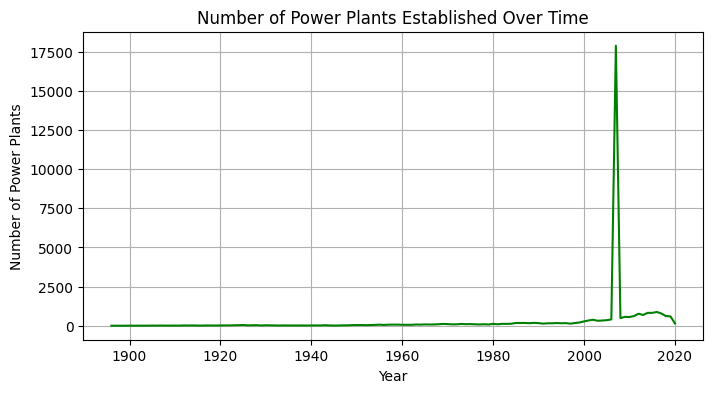

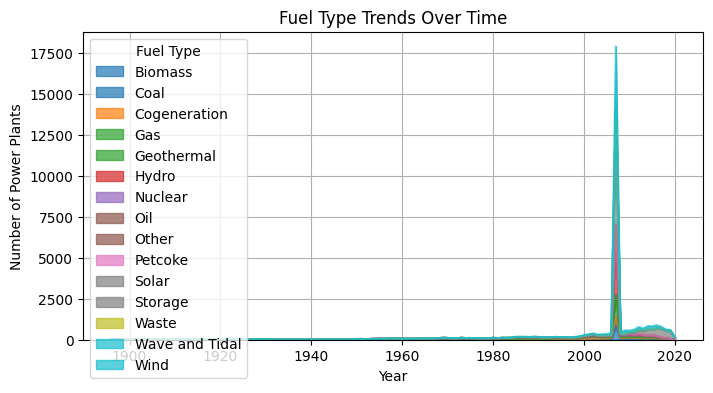

In [43]:
# Group by year to count the number of power plants established each year
plants_per_year = glpdf_cleaned.groupby('commissioning_year').size()

# Trends in fuel type mix over time
fuel_trends = glpdf_cleaned.groupby(['commissioning_year', 'primary_fuel']).size().unstack(fill_value=0)

# Visualization: Number of plants established over time
plt.figure(figsize=(8, 4))
plants_per_year.plot(kind='line', color='green')
plt.title('Number of Power Plants Established Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Power Plants')
plt.grid(True)
plt.show()

# Visualization: Fuel type trends over time
fuel_trends.plot(kind='area', stacked=True, figsize=(8, 4), alpha=0.7, colormap='tab10')
plt.title('Fuel Type Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Power Plants')
plt.legend(title='Fuel Type', loc='upper left')
plt.grid(True)
plt.show()


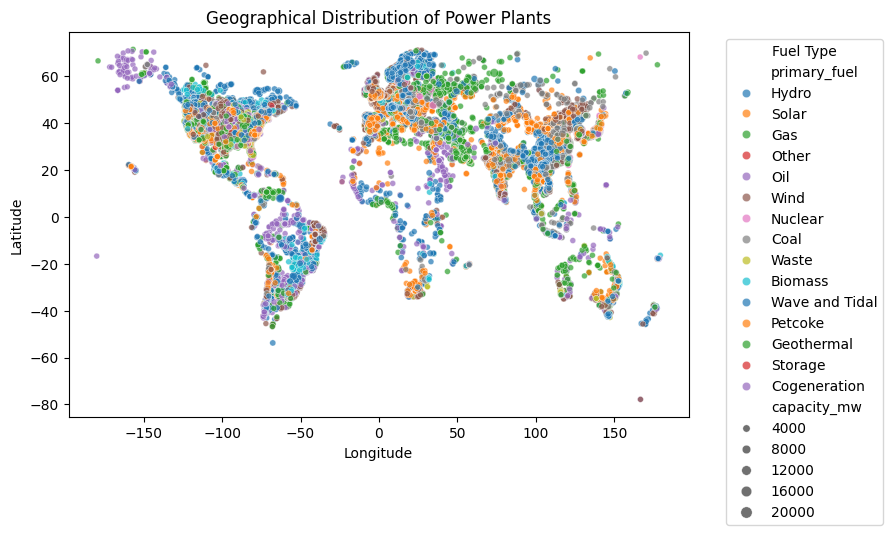

In [44]:
import seaborn as sns

# Plot geographical distribution of power plants
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=glpdf_cleaned,
    x='longitude',
    y='latitude',
    hue='primary_fuel',
    size='capacity_mw',
    alpha=0.7,
    palette='tab10'
)
plt.title('Geographical Distribution of Power Plants')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [40]:
# Create a matrix with selected numerical attributes
attributes = ['capacity_mw', 'latitude', 'longitude']
matrix = glpdf_cleaned[attributes].to_numpy().astype(float)

# Compute covariance matrix
cov_matrix = np.cov(matrix, rowvar=False)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nCovariance Matrix:")
print(cov_matrix)
print("\nEigenvalues:")
print(eigenvalues)
print("\nEigenvectors:")
print(eigenvectors)



Covariance Matrix:
[[ 2.39743483e+05 -1.46512725e+02  5.81707732e+03]
 [-1.46512725e+02  5.12506327e+02 -1.21328995e+02]
 [ 5.81707732e+03 -1.21328995e+02  6.14747738e+03]]

Eigenvalues:
[239888.34493566   6005.22827679    509.89320204]

Eigenvectors:
[[ 9.99690263e-01 -2.48871486e-02  9.13937503e-05]
 [-6.24482185e-04 -2.14133001e-02  9.99770514e-01]
 [ 2.48794803e-02  9.99460905e-01  2.14222092e-02]]


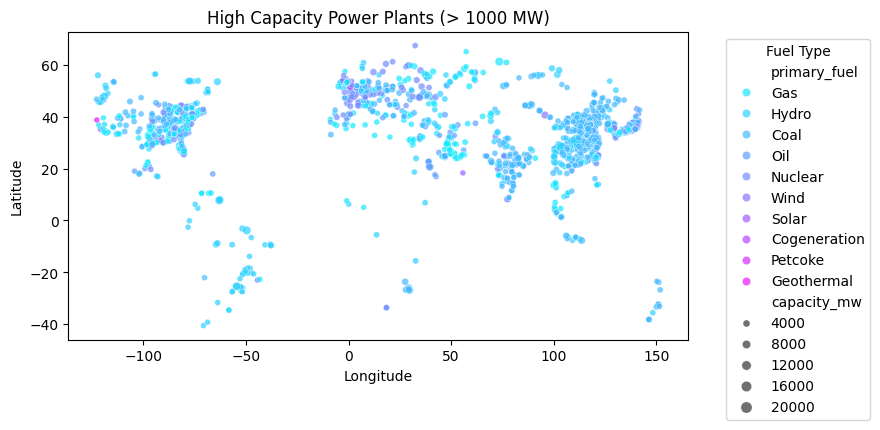

In [45]:
# Filter for high-capacity plants using NumPy
high_capacity_threshold = 1000  # MW
high_capacity_plants = glpdf_cleaned[np.array(glpdf_cleaned['capacity_mw'].astype(float) > high_capacity_threshold)]

# Plot filtered plants
plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=high_capacity_plants,
    x='longitude',
    y='latitude',
    hue='primary_fuel',
    size='capacity_mw',
    alpha=0.7,
    palette='cool'
)
plt.title('High Capacity Power Plants (> 1000 MW)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
